<a href="https://colab.research.google.com/github/Mariam-Elbishbeashy/HeadlineGeneration-NLP/blob/main/headlineGenerationNLP_AllTheNews_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets -q

In [ ]:
from datasets import load_dataset
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ds = load_dataset("rjac/all-the-news-2-1-Component-one")
ds

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['idx', 'article_idx', 'date', 'year', 'month', 'day', 'author', 'title', 'article', 'url', 'section', 'publication'],
        num_rows: 2688878
    })
})

In [ ]:
print(ds)
print(ds.keys())
print(ds["train"].column_names)
print("Number of rows:", len(ds["train"]))

DatasetDict({
    train: Dataset({
        features: ['idx', 'article_idx', 'date', 'year', 'month', 'day', 'author', 'title', 'article', 'url', 'section', 'publication'],
        num_rows: 2688878
    })
})
dict_keys(['train'])
['idx', 'article_idx', 'date', 'year', 'month', 'day', 'author', 'title', 'article', 'url', 'section', 'publication']
Number of rows: 2688878


# Exploratory Data Analysis (EDA)

### Exploratory Sample (5,000 Random Rows)

In [ ]:
explore_df = ds["train"].shuffle(seed=42).select(range(5000)).to_pandas()

In [ ]:
print("Shape:", explore_df.shape)
explore_df.head()

Shape: (5000, 12)


,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,30539,30539,2018-05-24,2018,5.0,24,Chaim Gartenberg,Internal documents reveal Apple knew the iPhon...,Recently released internal Apple documents (re...,https://www.theverge.com/circuitbreaker/2018/5...,Apple,The Verge
1,-27670,-27670,2016-04-26,2016,4.0,26,None,BRIEF-Steinhoff urges Darty investors to take ...,April 26 (Reuters) - Steinhoff : * Notes annou...,http://www.reuters.com/article/idUSFWN17S0X0,Financials,Reuters
2,17895,17895,2018-05-07,2018,5.0,7,Monica Chin,Mozilla's Pocket begins sticking sponsored con...,"Free browsers sound nice, but at the end of th...",https://mashable.com/2018/05/07/firefox-adding...,None,Mashable
3,6359,6359,2019-07-30,2019,7.0,30,None,"EMERGING MARKETS-Latam FX slip ahead of U.S, B...",None,https://www.reuters.com/article/emerging-marke...,Bonds News,Reuters
4,2823,2823,2017-05-16,2017,5.0,16,None,EU Commission says welcomes court ruling on tr...,BRUSSELS (Reuters) - The European Commission w...,http://www.reuters.com/article/us-eu-trade-cou...,Business News,Reuters


### Inspect Dataset Columns

In [ ]:
print("Columns:")
print(explore_df.columns.tolist())

Columns:
['idx', 'article_idx', 'date', 'year', 'month', 'day', 'author', 'title', 'article', 'url', 'section', 'publication']


### Dataset Data Types

In [ ]:
explore_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   idx          5000 non-null   int16 
 1   article_idx  5000 non-null   int16 
 2   date         5000 non-null   object
 3   year         5000 non-null   object
 4   month        5000 non-null   object
 5   day          5000 non-null   object
 6   author       3080 non-null   object
 7   title        5000 non-null   object
 8   article      4810 non-null   object
 9   url          4984 non-null   object
 10  section      3332 non-null   object
 11  publication  4984 non-null   object
dtypes: int16(2), object(10)
memory usage: 410.3+ KB


### Missing Values Analysis

In [ ]:
missing = explore_df.isnull().sum().sort_values(ascending=False)

print("Missing Values Per Column:")
print(missing)

Missing Values Per Column:
author         1920
section        1668
article         190
url              16
publication      16
date              0
article_idx       0
idx               0
year              0
title             0
month             0
day               0
dtype: int64


inspecting random values

In [ ]:
for i in range(3):
    print("="*100)
    print(f"ROW {i+1}")
    print(explore_df.iloc[i])

ROW 1
idx                                                        30539
article_idx                                                30539
date                                                  2018-05-24
year                                                        2018
month                                                        5.0
day                                                           24
author                                          Chaim Gartenberg
title          Internal documents reveal Apple knew the iPhon...
article        Recently released internal Apple documents (re...
url            https://www.theverge.com/circuitbreaker/2018/5...
section                                                    Apple
publication                                            The Verge
Name: 0, dtype: object
ROW 2
idx                                                       -27670
article_idx                                               -27670
date                                                  2

### section column Distribution for first 5000 rows (categories)

In [ ]:
explore_df["section"].value_counts().head(15)

,count
section,
Market News,206
World News,206
Business News,172
Wires,129
Financials,127
politics,97
us,90
Intel,84
Bonds News,74


### Publication column Distribution (Articles Sources)

In [ ]:
explore_df["publication"].value_counts().head(15)

,count
publication,
Reuters,1570
The New York Times,487
CNBC,435
The Hill,394
People,245
CNN,242
Refinery 29,215
Vice,185
Mashable,166


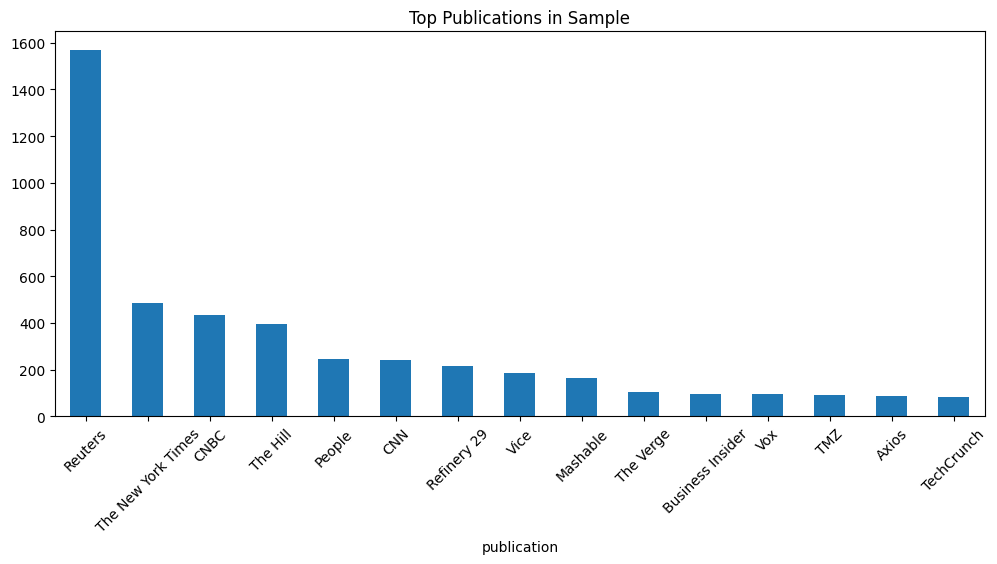

In [ ]:
plt.figure(figsize=(12,5))
explore_df["publication"].value_counts().head(15).plot(kind="bar")
plt.title("Top Publications in Sample")
plt.xticks(rotation=45)
plt.show()

### article Column Length

In [ ]:
explore_df["article_word_count"] = explore_df["article"].apply(
    lambda x: len(str(x).split())
)

In [ ]:
explore_df["article_word_count"].describe()

,article_word_count
count,5000.00000
mean,494.47500
std,542.54057
min,0.00000
25%,161.00000
50%,370.00000
75%,644.00000
max,11627.00000


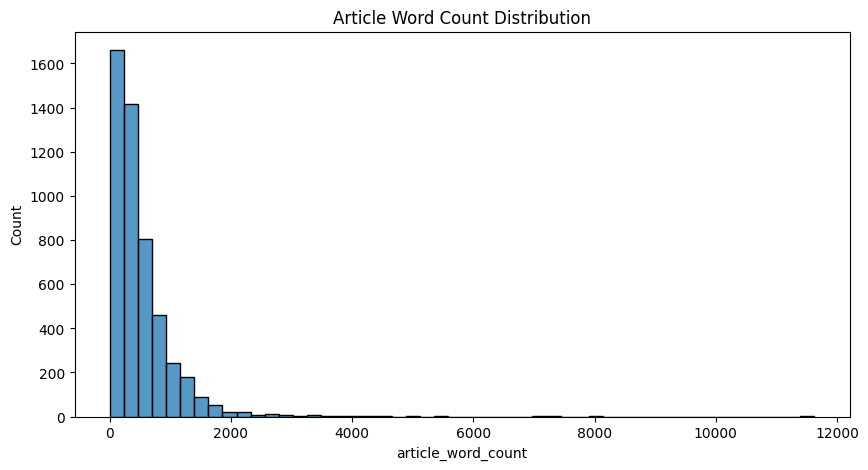

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(explore_df["article_word_count"], bins=50)
plt.title("Article Word Count Distribution")
plt.show()

### title Column Length

In [ ]:
explore_df["headline_word_count"] = explore_df["title"].apply(
    lambda x: len(str(x).split())
)

In [ ]:
explore_df["headline_word_count"].describe()

,headline_word_count
count,5000.000000
mean,10.085800
std,3.238354
min,1.000000
25%,8.000000
50%,10.000000
75%,12.000000
max,44.000000


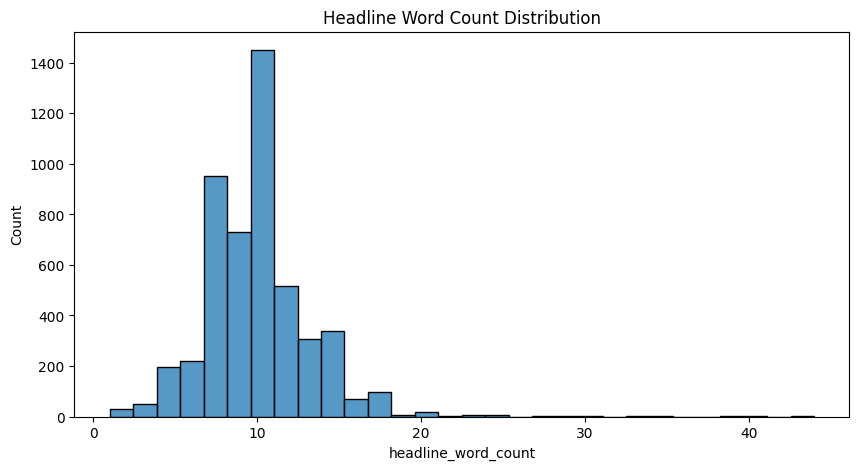

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(explore_df["headline_word_count"], bins=30)
plt.title("Headline Word Count Distribution")
plt.show()

### Inspecting Extreme Cases

Shortest Articles

In [ ]:
display(
    explore_df.sort_values("article_word_count").head(5)[
        ["article", "title", "article_word_count"]
    ]
)

,article,title,article_word_count
4320,,"CNN news quiz for the week ending November 23,...",0
3799,None,Anker sale: Save on devices for working from h...,1
3786,None,"Jim Lehrer, understated PBS news anchor and pr...",1
3,None,"EMERGING MARKETS-Latam FX slip ahead of U.S, B...",1
6,None,Nembhard scores 24 as Gators beat Aggies 78-61,1


Longest Articles

In [ ]:
display(
    explore_df.sort_values("article_word_count", ascending=False).head(5)[
        ["article", "title", "article_word_count"]
    ]
)

,article,title,article_word_count
4007,"On the latest episode of Recode Decode, Kara S...",‘The NFL is like a drug lord and football is l...,11627
2059,"Feature The original queen of pop on aging, in...",Madonna at Sixty,8025
4804,"On this episode of Recode Decode, hosted by Ka...",Full transcript: Shondaland CEO and TV produce...,7324
473,"On this episode of Too Embarrassed to Ask, the...",Full transcript: Girlboss CEO Sophia Amoruso o...,7180
4254,A new book by BuzzFeed News’s Global Investiga...,Putin’s Global Killing Campaign: How Kremlin A...,5361


Shortest Headlines

In [ ]:
display(
    explore_df.sort_values("headline_word_count").head(5)[
        ["title", "headline_word_count"]
    ]
)

,title,headline_word_count
4368,Refinery29,1
1495,Refinery29,1
3923,Refinery29,1
1325,Carol,1
2612,Not Found,2


Longest Headlines

In [ ]:
display(
    explore_df.sort_values("headline_word_count", ascending=False).head(5)[
        ["title", "headline_word_count"]
    ]
)

,title,headline_word_count
2092,Hillicon Valley: Tech tries to stop spread of ...,44
3648,Overnight Health Care — Presented by National ...,41
1576,On The Money: Conservative blocks disaster rel...,41
3593,Declaración falsa: Los médicos ofrecen recomen...,40
4640,Election Countdown: Recount prospects grow in ...,39


### Some Important Preprocessing Decisions


1.   missing values must be removed
2.   article length filter: 50-1000 (based on the histogram)
3.   title length filter: 3-20 (based on the histogram)






In [ ]:
before_rows = len(explore_df)

filtered_df = explore_df[
    (explore_df["article_word_count"] >= 50) &
    (explore_df["article_word_count"] <= 1000) &
    (explore_df["headline_word_count"] >= 3) &
    (explore_df["headline_word_count"] <= 20)
]

after_rows = len(filtered_df)

print("Rows before filtering:", before_rows)
print("Rows after filtering:", after_rows)
print("Rows removed:", before_rows - after_rows)
print("Percentage removed:", round((before_rows - after_rows)/before_rows*100, 2), "%")

Rows before filtering: 5000
Rows after filtering: 3940
Rows removed: 1060
Percentage removed: 21.2 %


In [ ]:
display(
    filtered_df.sort_values("article_word_count").head(5)[
        ["article", "title", "article_word_count"]
    ]
)

display(
    filtered_df.sort_values("article_word_count", ascending=False).head(5)[
        ["article", "title", "article_word_count"]
    ]
)

,article,title,article_word_count
1293,"PEOPLE Now airs live, Monday through Friday, f...",Beth Stern Shows Off These Amazing Pups That W...,50
2171,July 12 (Reuters) - VIFOR PHARMA AG: * ANNOUNC...,BRIEF-Vifor Pharma: three outcomes trials in h...,50
138,Oct 24 (Reuters) - Corbus Pharmaceuticals Hold...,BRIEF-Corbus Pharmaceuticals Holdings announce...,50
1897,Feb 24 (Reuters) - Anadolu Hayat: * Proposes t...,BRIEF-Anadolu Hayat proposes FY 2016 dividends,50
2466,Dec 18 (Reuters) - RECOMM Co Ltd : * Says it p...,BRIEF-RECOMM to issue new shares via private p...,50


,article,title,article_word_count
128,(CNN)An operation to recapture the northweste...,Yemen: Saudi-led forces launch attack on port ...,1000
3291,"New York (CNN Business)Don't look now, but pro...",American productivity is finally on the rise,999
2709,"Ask any comedian what they think of hecklers, ...",​Comedians Tell Us About Their Worst Hecklers,998
1681,The fire that destroyed two-thirds of the roof...,Fate of Priceless Cultural Treasures Uncertain...,998
4685,"In charges released Wednesday, the Justice Dep...",Twitter Insiders Allegedly Spied for Saudi Arabia,996


In [ ]:
display(
    filtered_df.sort_values("headline_word_count").head(5)[
        ["title", "headline_word_count"]
    ]
)

display(
    filtered_df.sort_values("headline_word_count", ascending=False).head(5)[
        ["title", "headline_word_count"]
    ]
)

,title,headline_word_count
1420,Education Secretary Approved,3
3196,CCTV Script 23/06/17,3
4183,CCTV Script 19/05/17,3
2391,Trump’s Budget Bluff,3
4861,Everyday Soviet Nostalgia,3


,title,headline_word_count
3505,Jordin Sparks Amazed to See Son DJ Grow: 'He T...,20
3680,NBA League Pass is launching Mobile View to ma...,20
3184,US blizzard: Midwest was already reeling from ...,20
3109,WWE Stars Lana and Rusev -- Perfect Wedding No...,20
4960,"With Plenty to Discuss, Senators Will Meet for...",20


In [ ]:
filtered_df.sample(10, random_state=42)[["title", "article"]]

,title,article
4539,BRIEF-Dowdupont declares quarterly dividend of...,Nov 2 (Reuters) - Dowdupont Inc: * Dowdupont d...
920,"Heat, water and plastic in France - Green on blue",IT WAS THE day the temperature reached a Frenc...
254,Santoli: Retail stocks' sell-off ruining chanc...,Santa looks to be a reindeer or two short to d...
1098,Victoria's Secret makes changes to shed its ol...,Victoria's SecretThings came to a head in Nove...
3421,Trump digs a hole in one,"Before the second presidential debate began, D..."
198,Trump likes Taylor Swift 'about 25 percent les...,LOS ANGELES (Reuters) - Taylor Swift’s decisio...
1554,"Thyssenkrupp, Tata Steel venture faces fresh u...",DUESSELDORF/FRANKFURT (Reuters) - Plans by Thy...
4916,Opinion | When Does Political Art Cross the Line?,Turning Points Turning Point: In a recent wave...
1551,A foreign disinformation campaign is targeting...,Democrats are already feeling the effects of ...
2121,"Apple HomePod: Price, Specs, Release Date",It's hard not to watch Amazon's Alexa and Goog...


In [ ]:
cctv_rows = explore_df[
    explore_df["title"].str.contains("CCTV Script", case=False, na=False)
]

print("Number of CCTV Script rows:", len(cctv_rows))

display(
    cctv_rows[["title", "article", "publication", "section"]].head(10)
)

Number of CCTV Script rows: 2


,title,article,publication,section
3196,CCTV Script 23/06/17,– This is the script of CNBC's news report for...,CNBC,Business News
4183,CCTV Script 19/05/17,– This is the script of CNBC's news report for...,CNBC,Business News


In [ ]:
sample_row = cctv_rows.iloc[0]

print("TITLE:")
print(sample_row["title"])

print("\nPUBLICATION:")
print(sample_row["publication"])

print("\nARTICLE:")
print(sample_row["article"][:3000])   # first 3000 chars

TITLE:
CCTV Script 23/06/17

PUBLICATION:
CNBC

ARTICLE:
– This is the script of CNBC's news report for China's CCTV on June 23, Friday. Welcome to CNBC Business Daily, I'm Qian Chen. U.S. banks made it through the latest round of stress testing relatively unscathed, setting investors up for news next week of payouts from the industry's biggest names. Testing results released Thursday by the Federal Reserve show that the 34 institutions under scrutiny have enough capital to make it through the two scenarios regulators posed - one akin to the financial crisis and another entailing a shallower downturn. Under the scenarios, the banks tested "would experience substantial losses." In the most severe scenario, bank losses are projected to be $493 billion. However, in total, the institutions "could continue lending to businesses and households, thanks to the capital built up by the sector following the financial crisis." Fed Governor Jerome H. Powell said in a statement, that ""This year's r

### Some Important Preprocessing Decisions


1.   missing values must be removed
2.   article length filter: 50-1000 (based on the histogram)
3.   title length filter: 3-20 (based on the histogram)
4.   removing articles with titles like 'CCTV Script 23/06/17' (Broadcast script / transcript)

In [ ]:
filtered_df["title"].value_counts().head(30)

,count
title,
Deals of the day-Mergers and acquisitions,4
The VICE Morning Bulletin,2
Milwaukee Brewers - PlayerWatch,2
Pompeo discusses Iran with Gulf allies amid escalating crisis,2
Start your Monday smart: What's happening this week,2
Arizona Diamondbacks - PlayerWatch,2
What the hell is the deal with Tether? – TechCrunch,1
'We are alive': Tokyo 2020 ceremonies to focus on rebirth,1
UK's Gatwick mulls using its emergency runway to boost capacity,1


In [ ]:
eval_sample = filtered_df.sample(100, random_state=42)[
    ["title", "article", "publication", "section"]
].reset_index(drop=True)

In [ ]:
for i, row in eval_sample.iterrows():
    print("="*100)
    print(f"SAMPLE {i+1}")
    print("TITLE:", row["title"])
    print("PUBLICATION:", row["publication"])
    print("SECTION:", row["section"])
    print("ARTICLE PREVIEW:", str(row["article"])[:300])
    print()

SAMPLE 1
TITLE: BRIEF-Dowdupont declares quarterly dividend of 38 cents per share, announces initial $4 billion share repurchase program
PUBLICATION: Reuters
SECTION: Market News
ARTICLE PREVIEW: Nov 2 (Reuters) - Dowdupont Inc: * Dowdupont declares quarterly dividend of 38 cents per share, announces initial $4 billion share repurchase program * Dowdupont Inc - dividend for Q4 of 2017 will be payable on Dec. 15, 2017, to shareholders of record on Nov. 15, 2017​ * Dowdupont Inc - ‍with a divi

SAMPLE 2
TITLE: Heat, water and plastic in France - Green on blue
PUBLICATION: Economist
SECTION: europe
ARTICLE PREVIEW: IT WAS THE day the temperature reached a French all-time record of 45.9°C (114.6°F). At the station in the sleepy Provençal town of Orange, a high-speed TGV train was being held indefinitely due to forest fires farther down the track, and passengers were wilting in the stifling heat. So the station 

SAMPLE 3
TITLE: Santoli: Retail stocks' sell-off ruining chances Dow 20,000
PU

In [ ]:
bad_patterns = [
    r"^BRIEF-",
    r"^UPDATE\s*\d*-",
    r"^REFILE-UPDATE\s*\d*-",
    r"^WRAPUP\s*\d*-",
    r"^PRESS DIGEST",
    r"FACTORS TO WATCH",
    r"^PREVIEW:",
    r"^Preview:",
    r"^Team by team analysis",
    r"^Pro Rata Podcast",
    r"^CCTV Script",
    r"^US STOCKS SNAPSHOT"
]

In [ ]:
combined_pattern = "|".join(bad_patterns)

filtered_df = filtered_df[
    ~filtered_df["title"].str.contains(
        combined_pattern,
        case=False,
        na=False,
        regex=True
    )
]

In [ ]:
before_rows = len(eval_sample)

filtered_df = eval_sample[
    ~eval_sample["title"].str.contains(
        combined_pattern,
        case=False,
        na=False,
        regex=True
    )
]

after_rows = len(filtered_df)

print("Rows before filtering:", before_rows)
print("Rows after filtering:", after_rows)
print("Rows removed:", before_rows - after_rows)
print("Percentage removed:", round((before_rows - after_rows) / before_rows * 100, 2), "%")

Rows before filtering: 100
Rows after filtering: 83
Rows removed: 17
Percentage removed: 17.0 %


In [ ]:
suspicious = filtered_df[
    filtered_df["title"].str.contains(
        combined_pattern,
        case=False,
        na=False,
        regex=True
    )
]

print("Remaining suspicious rows:", len(suspicious))
display(suspicious.head(20))

Remaining suspicious rows: 0


,idx,article_idx,date,year,month,day,author,title,article,url,section,publication,article_word_count,headline_word_count


# Applying some basic preprocessing steps on the full dataset (2.68M) before sampling

## Missing values removal

In [ ]:
full_ds = ds["train"]

print("Original full dataset size:", len(full_ds))

Original full dataset size: 2688878


In [ ]:
before_count = len(full_ds)

ds_no_missing = full_ds.filter(
    lambda x: x["article"] is not None and x["title"] is not None
)

after_count = len(ds_no_missing)

print("Before missing-value filtering:", before_count)
print("After missing-value filtering:", after_count)
print("Rows removed:", before_count - after_count)
print("Percentage removed:", round((before_count - after_count) / before_count * 100, 2), "%")

Before missing-value filtering: 2688878
After missing-value filtering: 2584149
Rows removed: 104729
Percentage removed: 3.89 %


## Filtlering the article and headline lengh

In [ ]:
def valid_lengths(example):
    article_wc = len(example["article"].split())
    title_wc = len(example["title"].split())

    return (
        50 <= article_wc <= 1000 and
        3 <= title_wc <= 20
    )

In [ ]:
before_count = len(ds_no_missing)

ds_length_filtered = ds_no_missing.filter(valid_lengths)

after_count = len(ds_length_filtered)

print("Before length filtering:", before_count)
print("After length filtering:", after_count)
print("Rows removed:", before_count - after_count)
print("Percentage removed:", round((before_count - after_count) / before_count * 100, 2), "%")

Filter:   0%|          | 0/2584149 [00:00<?, ? examples/s]

Before length filtering: 2584149
After length filtering: 2121450
Rows removed: 462699
Percentage removed: 17.91 %


# Removing templated/noisy titles

In [ ]:
combined_pattern = re.compile(
    r"^BRIEF-|"
    r"^UPDATE\s*\d*-|"
    r"^REFILE-UPDATE\s*\d*-|"
    r"^WRAPUP\s*\d*-|"
    r"^PRESS DIGEST|"
    r"FACTORS TO WATCH|"
    r"^PREVIEW:|"
    r"^Preview:|"
    r"^Team by team analysis|"
    r"^Pro Rata Podcast|"
    r"^CCTV Script|"
    r"^US STOCKS SNAPSHOT|"
    r"^Rising:\s*[A-Za-z]+\s+\d{1,2},\s+\d{4}\s*\|\s*TheHill",
    re.IGNORECASE
)

In [ ]:
def not_noisy_title(example):
    return not bool(combined_pattern.search(example["title"]))

In [ ]:
before_count = len(ds_length_filtered)

ds_template_filtered = ds_length_filtered.filter(not_noisy_title)

after_count = len(ds_template_filtered)

print("Before template-title filtering:", before_count)
print("After template-title filtering:", after_count)
print("Rows removed:", before_count - after_count)
print("Percentage removed:", round((before_count - after_count) / before_count * 100, 2), "%")

Before template-title filtering: 2121450
After template-title filtering: 1962825
Rows removed: 158625
Percentage removed: 7.48 %


In [ ]:
original_count = len(full_ds)
final_count = len(ds_template_filtered)

print("Original dataset size:", original_count)
print("Final cleaned dataset size:", final_count)
print("Total rows removed:", original_count - final_count)
print("Total percentage removed:", round((original_count - final_count) / original_count * 100, 2), "%")

Original dataset size: 2688878
Final cleaned dataset size: 1962825
Total rows removed: 726053
Total percentage removed: 27.0 %


## Exploring sections (categories) of the whole ds

In [ ]:
from collections import Counter

section_counts = Counter(
    section for section in ds_template_filtered["section"]
    if section is not None
)

for section, count in section_counts.most_common():
    print(f"{section}: {count}")

World News: 105082
Business News: 93716
politics: 43145
us: 32489
Market News: 32476
Politics: 31564
Wires: 31090
Intel: 26126
Sports News: 25686
tv: 23621
Bonds News: 21153
Financials: 20639
Tech: 20267
opinion: 18646
movies: 17899
Commodities: 17141
world: 16927
sports: 16504
business: 16198
Deals: 15785
style: 13208
arts: 12988
Technology News: 12637
Tech by VICE: 12151
Environment: 11336
Health News: 11056
crime: 10746
Entertainment: 10604
music: 9895
celebrity: 9787
health: 9542
Company News: 9362
Music by VICE: 9281
entertainment: 9193
U.S.: 8872
Energy: 8061
Food by VICE : 7920
nyregion: 7793
Big Story 10: 7389
Sports: 7354
fashion: 7138
parents: 6925
Entertainment News: 6783
Brexit: 6512
Cyclical Consumer Goods: 6425
opinions: 6316
Noisey: 5808
U.S. Legal News: 5786
Westlaw News: 5711
human-interest: 5599
royals: 5544
Healthcare: 5464
asia: 5341
Markets: 5158
pets: 5106
science: 4980
Wealth: 4928
Asia: 4896
Industrials: 4796
Market Insider: 4720
Apple: 4696
books: 4690
Google: 

## Decided to work on Politics + World + Tech + Crime for better results in headlines

In [ ]:
SECTION_MAP = {
    "politics": [
        "politics", "political", "policy", "elections", "white house",
        "congress", "supreme court", "u.s. elections", "democrats",
        "republicans", "government", "administration"
    ],

    "world": [
        "world", "world news", "u.s.", "u.s. news", "us", "united-states",
        "international", "europe news", "asia", "africa", "middleeast",
        "middle east", "world politics", "foreign policy"
    ],

    "tech": [
        "tech", "technology", "technology news", "science",
        "science news", "artificial intelligence",
        "cybersecurity", "privacy and security", "internet news",
        "space", "physics"
    ],

    "crime": [
        "crime", "crime and punishment", "criminal justice",
        "police and law enforcement", "terrorism", "homicide",
        "lawsuits", "legal", "u.s. legal news", "westlaw news"
    ]
}

In [ ]:
# reverse map: raw section -> meta category
section_to_meta = {}

for meta_category, section_list in SECTION_MAP.items():
    for section in section_list:
        section_to_meta[section] = meta_category

In [ ]:
# Function to normalize and map section
def add_meta_section(example):
    section = example["section"]

    if section is None:
        section_clean = ""
    else:
        section_clean = section.lower().strip()

    example["section_clean"] = section_clean
    example["meta_section"] = section_to_meta.get(section_clean, None)

    return example

In [ ]:
# Applying mapping on ds directly
ds_with_meta = ds_template_filtered.map(add_meta_section)

Map:   0%|          | 0/1963201 [00:00<?, ? examples/s]

In [ ]:
# Keeping only the 4 selected categories
ds_hard_news = ds_with_meta.filter(lambda x: x["meta_section"] is not None)

Filter:   0%|          | 0/1963201 [00:00<?, ? examples/s]

In [ ]:
from collections import Counter

section_counts = Counter(ds_hard_news["meta_section"])
section_counts

Counter({'world': 186259, 'politics': 81844, 'tech': 51186, 'crime': 24967})

In [ ]:
SAMPLES_PER_CLASS = 14000

balanced_parts = []

for category in ["politics", "world", "tech", "crime"]:
    category_ds = ds_hard_news.filter(lambda x: x["meta_section"] == category)

    sampled_category_ds = (
        category_ds
        .shuffle(seed=42)
        .select(range(SAMPLES_PER_CLASS))
    )

    balanced_parts.append(sampled_category_ds)

Filter:   0%|          | 0/344256 [00:00<?, ? examples/s]

Filter:   0%|          | 0/344256 [00:00<?, ? examples/s]

Filter:   0%|          | 0/344256 [00:00<?, ? examples/s]

Filter:   0%|          | 0/344256 [00:00<?, ? examples/s]

# Sampling 56k records from the initially cleaned dataset based on 4 categories (Politics + World + Tech + Crime)

In [ ]:
from datasets import concatenate_datasets

final_ds = concatenate_datasets(balanced_parts).shuffle(seed=42)

In [ ]:
from collections import Counter

print(len(final_ds))
print(Counter(final_ds["meta_section"]))

56000
Counter({'tech': 14000, 'politics': 14000, 'world': 14000, 'crime': 14000})


In [ ]:
final_df = final_ds.to_pandas()

## Checking for duplicates

In [ ]:
pair_duplicates = final_df.duplicated(
    subset=["article", "title"]
).sum()

print("Duplicate article-title pairs:", pair_duplicates)

Duplicate article-title pairs: 709


In [ ]:
before_rows = len(final_df)

final_df = final_df.drop_duplicates(
    subset=["article", "title"]
).reset_index(drop=True)

after_rows = len(final_df)

print("Rows before duplicate removal:", before_rows)
print("Rows after duplicate removal:", after_rows)
print("Duplicates removed:", before_rows - after_rows)
print("Percentage removed:", round((before_rows - after_rows)/before_rows*100, 2), "%")

Rows before duplicate removal: 56000
Rows after duplicate removal: 55291
Duplicates removed: 709
Percentage removed: 1.27 %


### Duplicate Articles With Different Titles

In [ ]:
duplicate_articles = final_df[
    final_df.duplicated(subset=["article"], keep=False)
].sort_values("article")

display(duplicate_articles[["title", "article"]].head(20))

,title,article
32355,Foreign affairs expert Gordon Chang reacts to ...,An overwhelming majority of voters are conc...
26430,Pollster quiz: How many Americans heat their h...,An overwhelming majority of voters are conc...
37192,"What America’s Thinking: August 16, 2018 | The...",An overwhelming majority of voters are conc...
28344,Alexandra Thornton discusses impact of tax cut...,Democratic strategist Antjuan Seawright sai...
21553,Dan Abrams talks new book with Hill.TV’s Joe C...,Democratic strategist Antjuan Seawright sai...
35045,Former Ambassador talks implications of Trump'...,Democratic strategist Antjuan Seawright sai...
23654,Chelsea Handler discusses political activism i...,Democratic strategist Antjuan Seawright sai...
31762,Reporter Mark Leibovich talks new book on NFL ...,Democratic strategist Antjuan Seawright sai...
48835,Panel: AOC battles Pelosi for the future of th...,Democratic strategist Antjuan Seawright sai...
31158,Full interview: Former Obama national security...,Democratic strategist Antjuan Seawright sai...


In [ ]:
before_rows = len(final_df)

final_df = final_df.drop_duplicates(
    subset=["article"],
    keep="first"
).reset_index(drop=True)

after_rows = len(final_df)

print("Rows before duplicate-article removal:", before_rows)
print("Rows after duplicate-article removal:", after_rows)
print("Rows removed:", before_rows - after_rows)
print("Percentage removed:", round((before_rows - after_rows)/before_rows*100, 2), "%")

Rows before duplicate-article removal: 49931
Rows after duplicate-article removal: 49860
Rows removed: 71
Percentage removed: 0.14 %


In [ ]:
final_df

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,-8290,-8290,2017-04-15 00:00:00,2017,4.0,15,Raymond Wong,It sure looks like the Galaxy S8's battery won...,Samsung's Galaxy S8 blends beautiful design a...,https://mashable.com/2017/04/15/samsung-galaxy...,None,Mashable
1,-16035,-16035,2017-11-06,2017,11.0,6,Andrea K. Scott,Five Centuries of Drawings at the Morgan,The almost unbearably excellent show “Drawn to...,https://www.newyorker.com/magazine/2017/11/06/...,magazine,New Yorker
2,8290,8290,2019-08-09,2019,8.0,9,"Justin Hill, Opinion Contributor",Retaliation tweets like Castro's to discourage...,"This week, Rep. Joaquin CastroJoaquin CastroTh...",https://thehill.com/blogs/congress-blog/politi...,None,The Hill
3,-15380,-15380,2018-12-10,2018,12.0,10,Michael Holden,UK court orders Indian tycoon Mallya to be ext...,LONDON (Reuters) - Indian tycoon Vijay Mallya ...,https://www.reuters.com/article/us-india-mally...,World News,Reuters
4,6079,6079,2018-01-01 00:00:00,2018,1.0,1,None,YouTuber Logan Paul Apologizes for Posting Vid...,Logan Paul is making a full mea culpa for post...,https://www.tmz.com/2018/01/01/youtuber-logan-...,None,TMZ
...,...,...,...,...,...,...,...,...,...,...,...,...
49855,11584,11584,2018-06-22,2018,6.0,22,Ed Cara,The FDA Has Approved an Implantable Glucose Mo...,"Eversense’s implantable sensor, seen above.Pho...",https://gizmodo.com/the-fda-has-approved-an-im...,Health,Gizmodo
49856,-16341,-16341,2018-07-02 13:00:00,2018,7.0,2,Farideh Sadeghin,Easy Peel-And-Eat Shrimp Recipe,Servings: 4Prep: 5 minutesTotal: 20 minutes fo...,https://www.vice.com/en_us/article/wjb94w/easy...,Food by VICE,Vice
49857,27544,27544,2018-12-04 00:00:00,2018,12.0,4,"Sara Fischer,",Slowing economy could increase pressure on Big...,"A potential recession, combined with increasin...",https://www.axios.com/recession-threat-2019-re...,None,Axios
49858,23733,23733,2016-11-02,2016,11.0,2,None,Brexit talks must cause as little friction as ...,"BERLIN, Nov 2 (Reuters) - German Chancellor An...",http://www.reuters.com/article/britain-eu-germ...,Bonds News,Reuters


In [ ]:
print(final_df["meta_section"].value_counts())

meta_section
politics    13931
world       13900
crime       13824
tech        13632
Name: count, dtype: int64


## Saving the sampled and initially cleaned df

In [ ]:
final_df.to_pickle("sampled_articles_dataset.pkl")